<a href="https://colab.research.google.com/github/GhostArcher20/GhostArcher20/blob/main/scatterplot-brezice2017.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

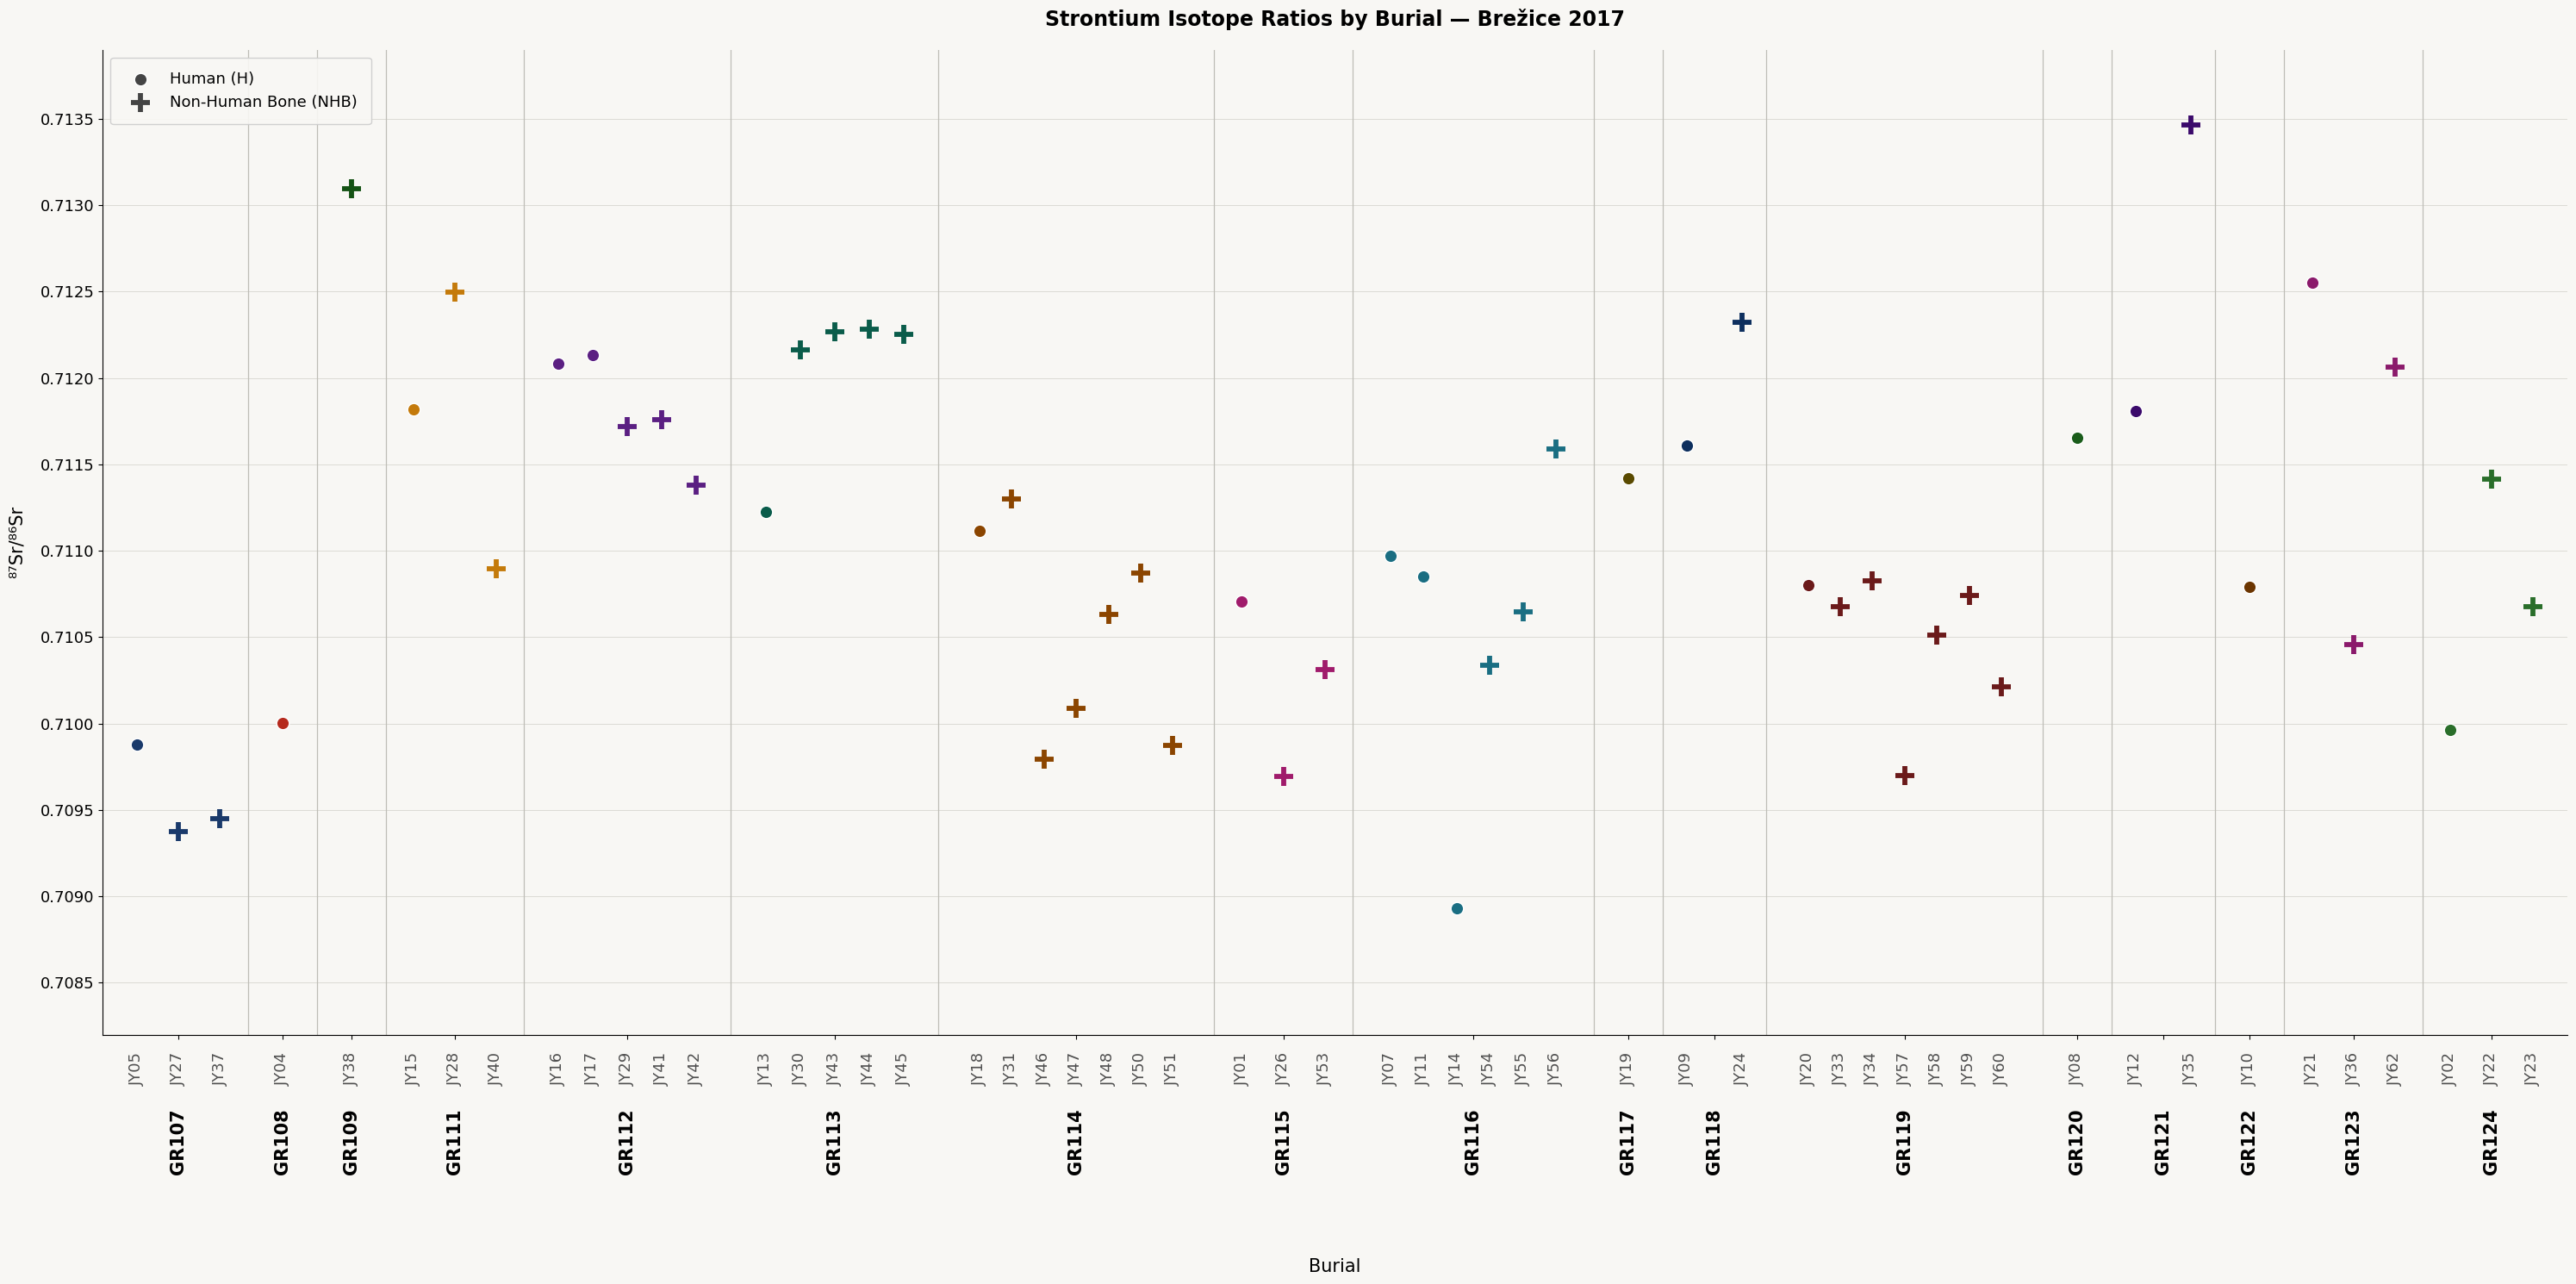

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

# ── 1. Load & clean data ────────────────────────────────────────────────────

df = pd.read_excel('test.xlsx', sheet_name='test')

# Keep only rows that have a numeric 87Sr/86Sr value
df_valid = df[pd.to_numeric(df['87Sr/86Sr'], errors='coerce').notna()].copy()
df_valid['87Sr/86Sr'] = pd.to_numeric(df_valid['87Sr/86Sr'])

# Normalise burial labels (e.g. "Gr107" → "GR107")
df_valid['burial_norm'] = df_valid['Burial n.'].str.upper().str.strip()

# Sort burials numerically
burials = sorted(
    df_valid['burial_norm'].unique(),
    key=lambda x: int(re.search(r'\d+', x).group())
)

# ── 2. Colour palette ────────────────────────────────────────────────────────
# 17 distinct, high-contrast colours — adjacent burials are visually different.
# Edit any colour here to suit your taste (hex codes).

palette = [
    '#1a3a6b',  # GR107 — dark navy
    '#b52a1d',  # GR108 — brick red
    '#145214',  # GR109 — dark green
    '#c47a0a',  # GR111 — amber
    '#5b1f82',  # GR112 — deep purple
    '#0a5c4a',  # GR113 — forest teal
    '#8b4500',  # GR114 — dark sienna
    '#a01b6b',  # GR115 — dark magenta
    '#1a6e82',  # GR116 — steel teal
    '#5a4a00',  # GR117 — dark olive
    '#0d2f5e',  # GR118 — deep blue
    '#6b1a1a',  # GR119 — maroon
    '#1a5c1a',  # GR120 — mid green
    '#3b0a6b',  # GR121 — deep violet
    '#6b3500',  # GR122 — dark brown
    '#8b1a6b',  # GR123 — wine
    '#2a6e2a',  # GR124 — darker green
]

burial_color = {b: palette[i] for i, b in enumerate(burials)}

# ── 3. Compute x-positions ───────────────────────────────────────────────────
# Each burial gets a group whose width scales with its sample count.
# Single-sample burials get a minimum width so they don't look squashed.

burial_data = {}
for b in burials:
    grp = df_valid[df_valid['burial_norm'] == b].copy()
    burial_data[b] = {
        'H':   grp[grp['H or NHB'] == 'H'].reset_index(drop=True),
        'NHB': grp[grp['H or NHB'] == 'NHB'].reset_index(drop=True),
    }

POINT_UNIT  = 0.50   # data-units of width per sample point
MIN_WIDTH   = 0.30   # minimum group width (for 1-sample burials)
GROUP_GAP   = 0.50   # gap between burial groups

x_pos = 0
burial_x_centers = {}
burial_widths    = {}
for b in burials:
    n = len(burial_data[b]['H']) + len(burial_data[b]['NHB'])
    w = max(n * POINT_UNIT, MIN_WIDTH)
    burial_x_centers[b] = x_pos + w / 2
    burial_widths[b]    = w
    x_pos += w + GROUP_GAP

def spread_xs(n, center, half_width):
    """Return n evenly-spaced x-coordinates centred on `center`."""
    if n == 1:
        return [center]
    return list(np.linspace(center - half_width, center + half_width, n))

# ── 4. Build the list of plot points ─────────────────────────────────────────

ANIMAL_MAP = {
    'mamal':                       'mammal',
    'Perdix perdix/Alectoris sp.': 'partridge',
    'young pig':                   'young pig',
    'large mammal':                'large mammal',
    'small mammal':                'small mammal',
    '?':                           'mammal?',
    'nan':                         '',
}

plot_points = []
for b in burials:
    center   = burial_x_centers[b]
    hw       = burial_widths[b] / 2 * 0.8
    h_rows   = burial_data[b]['H']
    nhb_rows = burial_data[b]['NHB']
    n_h, n_nhb = len(h_rows), len(nhb_rows)

    if n_h > 0 and n_nhb > 0:
        all_x  = spread_xs(n_h + n_nhb, center, hw)
        h_xs   = all_x[:n_h]
        nhb_xs = all_x[n_h:]
    else:
        h_xs   = spread_xs(n_h,   center, hw)
        nhb_xs = spread_xs(n_nhb, center, hw)

    for i, row in h_rows.iterrows():
        plot_points.append({
            'burial': b, 'sample': row['Sample n.'], 'type': 'H',
            'y': row['87Sr/86Sr'], 'x': h_xs[i],
            'animal': None, 'color': burial_color[b],
        })

    for i, row in nhb_rows.iterrows():
        raw    = str(row['type of animal']).strip() if pd.notna(row['type of animal']) else ''
        animal = ANIMAL_MAP.get(raw, raw)
        plot_points.append({
            'burial': b, 'sample': row['Sample n.'], 'type': 'NHB',
            'y': row['87Sr/86Sr'], 'x': nhb_xs[i],
            'animal': animal, 'color': burial_color[b],
        })

# ── 5. Figure & axes setup ───────────────────────────────────────────────────

FIG_W, FIG_H = 30, 15          # figure size in inches — adjust to taste

# Font sizes — increase all of these together to make text bigger
FS_SAMPLE  = 13.0   # sample-number labels below the axis
FS_BURIAL  = 15.0   # burial group labels (x-tick labels)
FS_YTICK   = 13.0   # y-axis tick values
FS_AXLABEL = 15.0   # axis titles ("Burial", "87Sr/86Sr")
FS_TITLE   = 17.0   # chart title
FS_LEGEND  = 13.0   # legend text

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
fig.patch.set_facecolor('#f8f7f4')
ax.set_facecolor('#f8f7f4')

# Y axis — 4 decimal places, one tick every 0.0005
all_y      = [p['y'] for p in plot_points]
y_start    = np.floor(min(all_y) / 0.0005) * 0.0005
y_end      = np.ceil(max(all_y)  / 0.0005) * 0.0005
yticks     = np.arange(y_start, y_end + 1e-9, 0.0005)

# Tighter margin pulled burial numbers and samples up
y_plot_min = y_start - 0.0003
y_plot_max = y_end + 0.0004

ax.set_ylim(y_plot_min, y_plot_max)
ax.set_yticks(yticks)
ax.set_yticklabels([f'{y:.4f}' for y in yticks], fontsize=FS_YTICK)

all_x_centers = [burial_x_centers[b] for b in burials]
# Calculate the actual left-most and right-most plotted points
all_x_coords = [p['x'] for p in plot_points]
# Add a generous fixed padding (e.g., 1.5 units) to the absolute edges
ax.set_xlim(min(all_x_coords) - 0.5, max(all_x_coords) + 0.5)

# Thin vertical dividers between burial groups
for i, b in enumerate(burials[:-1]):
    # Find the right edge of the current group, then add half the gap distance
    right_edge = burial_x_centers[b] + (burial_widths[b] / 2)
    x_mid = right_edge + (GROUP_GAP / 2)
    ax.axvline(x=x_mid, color='#bebdb6', linewidth=0.9, zorder=1)

# Horizontal gridlines
ax.yaxis.grid(True, linewidth=0.5, color='#d0cfc8', alpha=1, zorder=10)
ax.set_axisbelow(True)

# ── 6. Plot symbols ──────────────────────────────────────────────────────────

for pt in plot_points:
    if pt['type'] == 'H':
        ax.scatter(pt['x'], pt['y'], color=pt['color'],
                   s=110, zorder=5, marker='o',
                   edgecolors='white', linewidths=1.0)
    else:
        ax.scatter(pt['x'], pt['y'], color=pt['color'],
                   s=260, zorder=5, marker='+', linewidths=4.2)

# ── 7. Sample-number labels below each point ─────────────────────────────────

for pt in plot_points:
    ax.text(
        pt['x'], y_plot_min - 0.00010, pt['sample'],
        rotation=90, fontsize=FS_SAMPLE, color='#505050',
        ha='center', va='top', clip_on=False, zorder=7,
    )

# ── 8. Axis labels & formatting ──────────────────────────────────────────────

ax.set_xticks(all_x_centers)
ax.set_xticklabels(burials, rotation=90, fontsize=FS_BURIAL,
                   ha='center', fontweight='bold')
ax.tick_params(axis='x', pad=58)

ax.set_ylabel('⁸⁷Sr/⁸⁶Sr', fontsize=FS_AXLABEL, labelpad=12)
ax.set_xlabel('Burial',     fontsize=FS_AXLABEL, labelpad=70)
ax.set_title(
    'Strontium Isotope Ratios by Burial — Brežice 2017',
    fontsize=FS_TITLE, pad=20, fontweight='bold',
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── 9. Legend ────────────────────────────────────────────────────────────────

dot  = plt.scatter([], [], marker='o', color='#444', s=110,
                   label='Human (H)', edgecolors='white', linewidths=1.0)
plus = plt.scatter([], [], marker='+', color='#444', s=260,
                   label='Non-Human Bone (NHB)', linewidths=4.2)
ax.legend(
    handles=[dot, plus], loc='upper left',
    framealpha=0.9, fontsize=FS_LEGEND,
    frameon=True, edgecolor='#cccccc', facecolor='#f8f7f4',
    handletextpad=0.9, borderpad=0.9,
)

# ── 10. Save & Display ───────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig('strontium_scatter.png', dpi=200, bbox_inches='tight')
plt.show()